In [99]:
!pip install xlrd


[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


# Answer Key
## Problem 1 Part A
1. R-squared: 0.622 Coefficients: ['183.2956', '-213.3340']
2. see above
3. 27,331,954 customers predicted

## Problem 1 Part B
1. Coefficient: 0.0217, Intercept: -98.5080, R^2 score: 0.8187
2. see above
3. 440.51 - 98.5080 = 342.002 \$34,200,200 `or` \$34.2 million

## Problem 2
1. Gradient Descent: slope: .002, intercept: .35
2. OLS Regression: slope: .28, intercept: 46.45

In [100]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

In [101]:
data_airline = pd.read_csv('Assignment-2_Problem 1_airline-costs.csv', header=None)

In [102]:
# Add header to csv
# These are the header columns
# Airline Length of flight (miles), Speed of plane (miles per hour), Daily flight time per plane (hours), Population served (1000s), Total operating cost (cents per revenue ton-mile), Revenue tons per aircraft mile, Ton-mile load factor (proportion), Available capacity (tons per mile), Total assets ($100,000s), Investments and special funds ($100,000s), Adjusted assets ($100,000s)
columns = [
    "airline",
    "flight_len",
    "speed",
    "daily_flight_hrs",
    "pop_served",
    "op_cost",
    "rev_tons_per_mile",
    "load_factor",
    "cap_tons_mile",
    "assets",
    "invest_funds",
    "adj_assets"
]
data_airline.columns = columns

In [103]:
display(data_airline)

,airline,flight_len,speed,daily_flight_hrs,pop_served,op_cost,rev_tons_per_mile,load_factor,cap_tons_mile,assets,invest_funds,adj_assets
0,All American,57,133,6.10,20200,116.3,0.96,0.400,2.400,21.13,3.21,17.92
1,American,270,216,6.93,56928,43.0,3.98,0.689,5.776,1436.53,165.22,1271.31
2,Bonanza,100,140,4.45,183,141.5,0.79,0.358,2.207,6.65,0.01,6.64
3,Braniff,176,182,6.60,11869,50.6,2.57,0.557,4.614,160.30,5.81,154.49
4,Capital,142,167,7.47,41097,51.0,2.68,0.510,5.255,195.02,6.06,188.96
5,Central,51,134,4.67,1757,318.5,0.35,0.167,2.096,14.02,0.01,14.01
6,C&S,175,175,8.60,18000,59.2,2.17,0.558,3.889,114.16,3.11,111.05
7,Colonial,112,150,6.87,13500,77.0,1.68,0.505,3.327,35.34,0.79,34.55
8,Continental,131,179,6.50,3831,62.3,1.70,0.537,3.166,49.74,3.49,46.25
9,Delta,174,191,7.60,13119,45.3,2.74,0.598,4.582,174.32,3.87,170.45


In [104]:
data_airline.shape

(31, 12)

In [105]:
df_airline = data_airline.copy()

# Part A [3 Points]

1. Use a linear regression model to predict the number of customers each airline serves from its length of the flight and daily flight time per plane.

2. Report your model (linear equation).

3. What is your predicted value for the number of customers served for a flight that is 200 miles in length and has a daily flight time per plane of 7.2 hours?

In [106]:
import numpy as np
np.random.seed(7)

X = df_airline[["daily_flight_hrs", "flight_len"]]
y = df_airline["pop_served"]

X = sm.add_constant(X)

reg_model = sm.OLS(y, X).fit()

print(reg_model.summary())

                            OLS Regression Results                            
Dep. Variable:             pop_served   R-squared:                       0.622
Model:                            OLS   Adj. R-squared:                  0.595
Method:                 Least Squares   F-statistic:                     23.00
Date:                Thu, 09 Oct 2025   Prob (F-statistic):           1.23e-06
Time:                        13:44:42   Log-Likelihood:                -330.06
No. Observations:                  31   AIC:                             666.1
Df Residuals:                      28   BIC:                             670.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -7792.0706   8396.998  

In [126]:
# scikit-learn
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, y)
print(model.coef_, model.intercept_)

# statsmodels
import statsmodels.api as sm
X_const = sm.add_constant(X)
ols_model = sm.OLS(y, X_const).fit()
print(ols_model.summary())

[0.         0.28761237] 46.45081362636077
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.777
Model:                            OLS   Adj. R-squared:                  0.772
Method:                 Least Squares   F-statistic:                     149.7
Date:                Thu, 09 Oct 2025   Prob (F-statistic):           1.34e-15
Time:                        16:01:19   Log-Likelihood:                -182.98
No. Observations:                  45   AIC:                             370.0
Df Residuals:                      43   BIC:                             373.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const     

### Part A Analysis:
When using linear regression to conduct an analysis of the relationship between the outcome, population of customers served, to the variables: daily flight time per plane in hours and length of flight in miles, we get an r-squared value of 0.62. This means the model only explains 62% of the variation in population of customers served. Also, the p-value for the daily flight time per plane in hours is 0.883 which makes it too high to be statistically significant. The relationship between this variable and population served is a negative one. For every increase in daily flight time, the population served will decrease 213.33. The length of flight in miles is highly significant to the population of customers served based on the low p-value. The relationship between this variable and the outcome is positive. For every length of flight mile increase the population served will increase by 183.30. <p>
The linear equation for this model is:<p>
$$y = -213.33\,x_1 + 183.30\,x_2 - 7792.07$$

#### Answer for 3.
What is your predicted value for the number of customers served for a flight that is 200 miles in length and has a daily flight time per plane of 7.2 hours?<p>
The predicted value of customers served on a flight that is 200 miles in length and 7.2 hours long is:<p>
$$y = -213.33*7.2 + 183.30*200 - 7792.07 $$
$$y = 27331.954 $$
Since the data has customers in the thousands `Population served (1000s)` we have to multiply our answer by 1000 to get the number of customers served:<p>
27,331,954 customers predicted

## Part B [3 Points]
1. Next, build another regression model to predict the total assets of an airline from the customer served by the airline.

2. Once again, report your model.

3. What is your prediction for total assets for an airline, given they serve 20,300,000 customers?

In [107]:
X = df_airline["pop_served"]
y = df_airline["assets"]

X = sm.add_constant(X)

reg_model = sm.OLS(y, X).fit()

print(reg_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 assets   R-squared:                       0.819
Model:                            OLS   Adj. R-squared:                  0.812
Method:                 Least Squares   F-statistic:                     130.9
Date:                Thu, 09 Oct 2025   Prob (F-statistic):           2.85e-12
Time:                        13:44:42   Log-Likelihood:                -202.95
No. Observations:                  31   AIC:                             409.9
Df Residuals:                      29   BIC:                             412.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -98.5080     41.633     -2.366      0.0

### Part B Analysis
This linear regression model analyzes the relationship between the total assets of an airline using the variable of population served. The R-squared score is 0.819 meaning this model explains approximately 82% of the variation in total assets. The p-value of 0.00 identifies this variable as statistically significant. The population served has a positive relationship with the total assets. For every increase of 1 (1000s) population served, the total assets will increase by .0217.<p>
The linear equation for this model is:<p>
 $$y = 0.0217\,m - 98.5080$$

#### Answer
Note the units of each variable:
Population served (1000s)
Total assets ($100,000s)

Q: What is your prediction for total assets for an airline, given they serve 20,300,000 customers?<p>

 According to this model, the predicted value for total assets of 20,300,000 customers is:<p>
$$y = 0.0217*20300 - 98.5080$$
$$y = 440.51 - 98.5080$$
$$y = 342.002$$
<p>
y is in units of \$100,000s so \$34,200,200 or \$34.2 million

# Problem 2
1. Use the gradient descent algorithm to predict the optimal intercept and gradient for this problem. Report your gradient values. [4 points]

In [108]:
data_roo = pd.read_excel('Assignment-2_Problem-2_kangaroo.xls', engine='xlrd')

*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'


In [109]:
data_roo.head()

,X,Y
0,609,241
1,629,222
2,620,233
3,564,207
4,645,247


In [110]:
df_roo = data_roo.copy()

In [111]:
X = df_roo["X"].to_numpy(dtype=float)
y = df_roo["Y"].to_numpy(dtype=float)

n = len(y)

#Calculating the Mean Squared Error
def f(t):
    b0, b1 = t 
    y_preds = b0 + b1 * X
    return np.mean((y - y_preds)**2) 
    
def grad(t):
    b0, b1 = t
    y_preds = b0 + b1 * X
    res_error = y - y_preds
    db0 = -(2/n) * np.sum(res_error)
    db1 = -(2/n) * np.sum(X * res_error)
    return np.array([db0, db1]) #return new slope and intercept

def minimize_f(grad_fn, t0, alpha, tol=1e-4, max_iter=1000, verbose=True):
    t = np.array(t0, dtype=float)
    i = 0

    while np.linalg.norm(grad_fn(t)) >= tol and i < max_iter:
        if verbose and i % 100 == 0:
            print(f"iter={i}, t={t}, cost={f(t):.4f}, |grad|={np.linalg.norm(grad_fn(t)):.4f}") 
        t = t - alpha * grad_fn(t) # update slope and intercept
        i += 1
    print("Best t:", t, "with cost", f(t))
    return t
#OpenAI (2025) was used to convert sample of gradient descent code provided in live course to fit data set for problem 2. Step by step explanation was generated and then debugging was completed in ChatGPT. 

Reference: OpenA.(2025).ChatGPT(October 4 version)[Large language model]. https://chat.openai.com/

In [112]:
best_t = minimize_f(grad, t0=[0.0, 0.0], alpha=1e-7, max_iter=10000)

iter=0, t=[0. 0.], cost=60505.1778, |grad|=340491.0168
iter=100, t=[0.0005222  0.35399312], cost=236.9284, |grad|=13.9055
iter=200, t=[0.00053842 0.35400746], cost=236.9283, |grad|=1.6206
iter=300, t=[0.00055463 0.35400744], cost=236.9283, |grad|=1.6206
iter=400, t=[0.00057083 0.35400741], cost=236.9283, |grad|=1.6206
iter=500, t=[0.00058704 0.35400739], cost=236.9282, |grad|=1.6206
iter=600, t=[0.00060325 0.35400737], cost=236.9282, |grad|=1.6206
iter=700, t=[0.00061945 0.35400734], cost=236.9282, |grad|=1.6206
iter=800, t=[0.00063566 0.35400732], cost=236.9281, |grad|=1.6206
iter=900, t=[0.00065186 0.3540073 ], cost=236.9281, |grad|=1.6206
iter=1000, t=[0.00066807 0.35400727], cost=236.9281, |grad|=1.6206
iter=1100, t=[0.00068427 0.35400725], cost=236.9281, |grad|=1.6206
iter=1200, t=[0.00070048 0.35400723], cost=236.9280, |grad|=1.6206
iter=1300, t=[0.00071669 0.3540072 ], cost=236.9280, |grad|=1.6206
iter=1400, t=[0.00073289 0.35400718], cost=236.9280, |grad|=1.6206
iter=1500, t=[0

Problem 2 Analysis: When using Gradient Descent to find the optimal slope and intercept for the lowest errors in this model, my iterations landed at a slope of .002 and an intercept of .35. I completed a linear regression analysis to compare these findings and I see they are vastly different. The OLS regression analysis determines a slope of .28 and an intercept of 46.45. My hypothesis is the error in my gradient descent has to do with the scale. I completed a small batch of the data points by hand for 2 iterations and the numbers changed drastically. I will try another version of gradient descent below to see if I can get closer.   

In [113]:
# OLS Regression to compare first gradient descent results. 
X = df_roo["X"]
y = df_roo["Y"]

X = sm.add_constant(X)

reg_model = sm.OLS(y, X).fit()

print(reg_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.777
Model:                            OLS   Adj. R-squared:                  0.772
Method:                 Least Squares   F-statistic:                     149.7
Date:                Thu, 09 Oct 2025   Prob (F-statistic):           1.34e-15
Time:                        13:44:42   Log-Likelihood:                -182.98
No. Observations:                  45   AIC:                             370.0
Df Residuals:                      43   BIC:                             373.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         46.4508     16.300      2.850      0.0

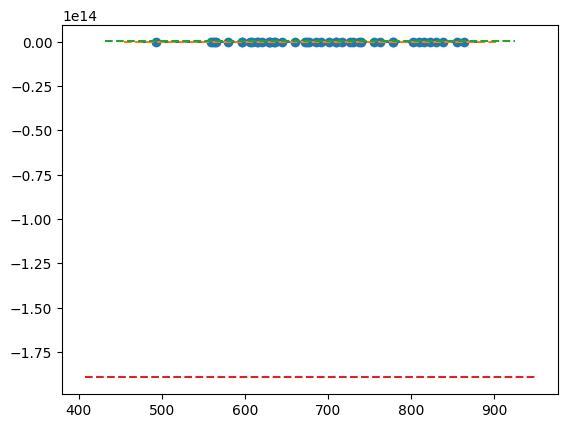

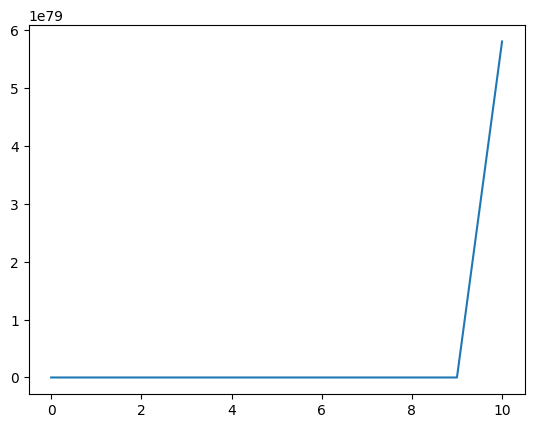

In [125]:
# From Sophin
# Now we will work on gradient descent
# Define our cost function
import matplotlib.pyplot as plt

def cost(X, y, theta):
    return(sum(np.matmul(X, theta) - y)**2 / (2*len(y)))
# Initialize coefficients
theta = np.matrix([[0],[0]])
num_iterations = 10
alpha = 0.01

# Store the history
cost_history = [float(num_iterations)]
theta_history = [[num_iterations]]

#Appending ones
X = np.append(np.ones([len(data_roo),1]), np.array(data_roo.X).reshape(len(data_roo.X),1), 1)

# Gradient descent algorithm
for i in range(1, num_iterations+1):
    error = np.matmul(X, theta) - np.array(data_roo.Y).reshape(len(data_roo.Y),1)
    delta = np.matmul(np.transpose(X), error) / len(data_roo.Y)
    theta = theta - alpha * delta
    #print(theta)
    # When appending to cost_history, convert to float
    cost_val = cost(X, np.array(data_roo.Y).reshape(len(data_roo.Y),1), theta)
    cost_history.append(cost_val.item() if hasattr(cost_val, "item") else float(cost_val))
    theta_history.append([theta])

#Function to plot a line given slope and intercept
def abline(slope, intercept):
    """Plot a line from slope and intercept"""
    axes = plt.gca()
    x_vals = np.array(axes.get_xlim())
    y_vals = intercept + slope * x_vals
    plt.plot(x_vals, y_vals, '--')

#Plotting the data
plt.figure()
plt.scatter(data_roo.X, data_roo.Y)
# Extract scalar values using .item()
abline(theta_history[1][0][0].item(), theta_history[1][0][1].item())
abline(theta_history[1][0][0].item(), theta_history[2][0][1].item())
abline(theta_history[1][0][0].item(), theta_history[3][0][1].item())
abline(theta_history[1][0][0].item(), theta_history[4][0][1].item())
plt.show()
# We can scale the plot in order to see better results
# Plotting the cost function
plt.plot(cost_history)

In [114]:
# Student
# New Gradient Descent attempt as the previous attempt provided inaccurate results:
def best_m_and_c(X, Y, m, c, alpha):
    dl_dm = 0.0
    dl_dc = 0.0
    n = len(X)

    for i in range(n):
        dl_dm += -2*X[i]*(Y[i] - (m*Y[i] + c))
        dl_dc += -2*(Y[i] - (m*X[i] + c))

    m = m - (1/float(n))*dl_dm*alpha
    c = c - (1/float(n))*dl_dc*alpha

    return m, c

In [115]:
def avg_loss(X, Y, m, c):
    n = len(X)
    total_error = 0.0
    for i in range (n):
        total_error += (Y[i] - (m*X[i] + c))**2
    return total_error / float(n)

In [116]:
def train(X, Y, m, c, alpha, epochs):
    for e in range(epochs):
        m, c = best_m_and_c(X, Y, m, c, alpha)

        if e % 400 == 0:
            print("epoch:", e, "loss:", avg_loss(X, Y, m, c))
    return m, c

In [117]:
X = df_roo["X"].to_numpy(dtype=float)
Y = df_roo["Y"].to_numpy(dtype=float)
m = 0.0
c = 0.0
alpha = 1e-7
epochs = 10000

m , c = train(X, Y, m, c, alpha, epochs)
print("Best slope:", m)
print("Best Interept:", c)

epoch: 0 loss: 49469.30200114614
epoch: 400 loss: 200966.36997087143
epoch: 800 loss: 201024.4895436214
epoch: 1200 loss: 201082.04981073592
epoch: 1600 loss: 201139.62653213766
epoch: 2000 loss: 201197.2197130685
epoch: 2400 loss: 201254.8293582196
epoch: 2800 loss: 201312.45547228208
epoch: 3200 loss: 201370.098059951
epoch: 3600 loss: 201427.7571259196
epoch: 4000 loss: 201485.4326748851
epoch: 4400 loss: 201543.12471154428
epoch: 4800 loss: 201600.8332405959
epoch: 5200 loss: 201658.5582667406
epoch: 5600 loss: 201716.29979467983
epoch: 6000 loss: 201774.05782911592
epoch: 6400 loss: 201831.83237475343
epoch: 6800 loss: 201889.62343629746
epoch: 7200 loss: 201947.43101845565
epoch: 7600 loss: 202005.25512593516
epoch: 8000 loss: 202063.09576344737
epoch: 8400 loss: 202120.9529356999
epoch: 8800 loss: 202178.82664740735
epoch: 9200 loss: 202236.71690328294
epoch: 9600 loss: 202294.62370804127
Best slope: 1.0035587721558472
Best Interept: -0.8839981531711493


The structure for this code was taken from Burkov (2019), The Hundred-Page Machine Learning Book. This code is closest to the algorithm from Dr. Shah's videos and reference materials. I adapted it to match my variables and the variables Dr. Shah used in equations. 
Reference: Burkov, A. (2019). The hundred-page machine learning book. (Andriy Burkov)

### Problem 2 Additional Reflection
I am still getting a different slope and intercept using the gradient descent method. According to my updated attempt at iteration 9200 the loss is at it lowest with a value of 200924.91798. In iteration 9600 the loss begins to rise again which means we are leaving the best slope and intercept for the least prediction errors. The optimal slope and intercept provided are 1.0036 and -0.883998. This is still in contrast with the OLS results of .2876 and 46.4508. While I am conflicted by the results, this version of code is inline with my python and computation comprehension. I look forward to the feedback from the grading of this assignment to further my understanding of the errors.

In [127]:
df_roo.shape

(45, 2)